In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
sns.set(style="whitegrid")

In [88]:
# --- Load data ---
df_demo = pd.read_csv("../data/demographic_data.csv") 
df_sleep = pd.read_csv("../data/Quest_sleep.csv")
df_hyp = pd.read_csv("../data/merged_demo_hypertensive_bmi_data.csv")[['Participant_ID', 'Hypertensive']]
df_nutrient = pd.read_csv("../data/dietary_data/dietary_nutrient_avg_data.csv")[['seqn_no', 'nutrient_score']]


# --- Preprocessing & Merging ---
df_sleep = df_sleep.rename(columns={'seqn_no': 'Participant_ID'})
df_nutrient=  df_nutrient.rename(columns={'seqn_no': 'Participant_ID'})
df = df_demo.merge(df_sleep, on='Participant_ID', how='right')
df = df.merge(df_hyp, on='Participant_ID', how='inner')
df = df.merge(df_nutrient, on='Participant_ID', how='inner')

In [89]:
# --- Filter valid adult records ---
df = df[(df['Age_Years'] >= 20) & df['Hypertensive'].notna() & (df['Exam_Weight'] > 0)]
df = df[df['avg_sleep_hrs'].notna() & df['Gender'].notna()]



In [90]:
# --- Create clear sleep duration categories ---
df['sleep_category'] = pd.cut(
    df['avg_sleep_hrs'],
    bins=[0, 6, 8, 10, 24],
    labels=['<6 hrs', '6–8 hrs', '8–10 hrs', '>10 hrs'],
    include_lowest=True,
    right=False
)

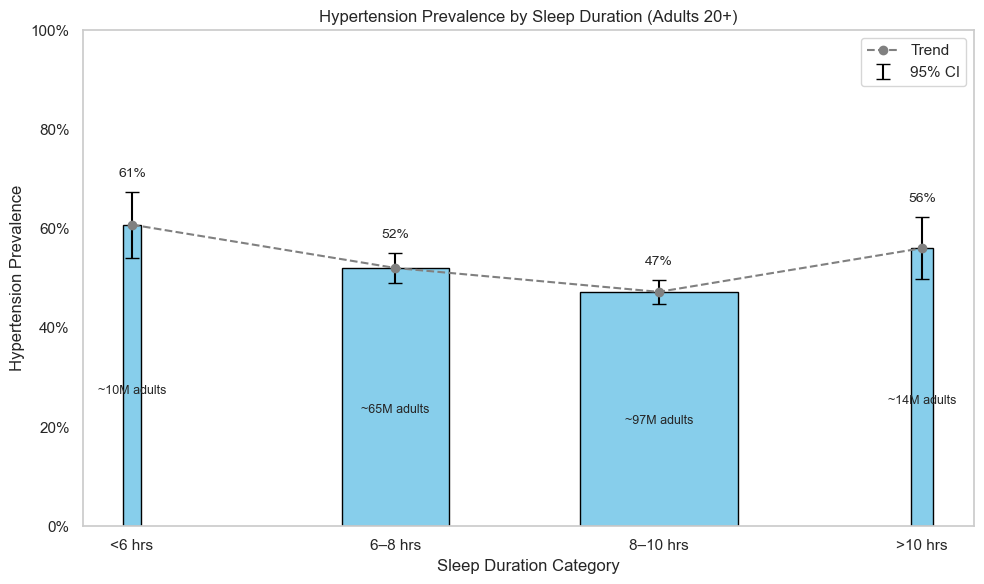

In [91]:


# --- Drop NaN categories ---
df = df[df['sleep_category'].notna()]

# --- Set category order ---
cat_order = ['<6 hrs', '6–8 hrs', '8–10 hrs', '>10 hrs']
df['sleep_category'] = pd.Categorical(df['sleep_category'], categories=cat_order, ordered=True)

# --- Weighted prevalence function ---
def compute_weighted_ci(group):
    weights = group['Exam_Weight']
    p = np.average(group['Hypertensive'], weights=weights)
    weight_sum = weights.sum()
    weight_sq_sum = (weights ** 2).sum()
    n_eff = (weight_sum ** 2) / weight_sq_sum
    se = np.sqrt(p * (1 - p) / n_eff)
    ci_lower = max(0, p - 1.96 * se)
    ci_upper = min(1, p + 1.96 * se)
    return pd.Series({
        'Weighted_Hypertension_Prevalence': p,
        'CI_Lower': ci_lower,
        'CI_Upper': ci_upper,
        'Weighted_Population': weight_sum
    })

# --- Group by sleep category ---
sleep_cat_results = df.groupby('sleep_category').apply(compute_weighted_ci).reset_index()
sleep_cat_results = sleep_cat_results.sort_values('sleep_category').reset_index(drop=True)
sleep_cat_results['Norm_Pop'] = sleep_cat_results['Weighted_Population'] / sleep_cat_results['Weighted_Population'].max()

# --- Plotting ---
plt.figure(figsize=(10, 6))
bar_positions = np.arange(len(sleep_cat_results))

bars = plt.bar(
    bar_positions,
    sleep_cat_results['Weighted_Hypertension_Prevalence'],
    width=sleep_cat_results['Norm_Pop'] * 0.6,
    color='skyblue',
    edgecolor='black'
)

# --- Error bars ---
plt.errorbar(
    x=bar_positions,
    y=sleep_cat_results['Weighted_Hypertension_Prevalence'],
    yerr=[
        sleep_cat_results['Weighted_Hypertension_Prevalence'] - sleep_cat_results['CI_Lower'],
        sleep_cat_results['CI_Upper'] - sleep_cat_results['Weighted_Hypertension_Prevalence']
    ],
    fmt='none', ecolor='black', capsize=5, label="95% CI"
)

# --- Labels ---
for i, row in sleep_cat_results.iterrows():
    percent = int(round(row['Weighted_Hypertension_Prevalence'] * 100))
    pop_m = int(round(row['Weighted_Population'] / 1_000_000))
    plt.text(i, row['Weighted_Hypertension_Prevalence'] * 0.45,
             f"~{pop_m}M adults", ha='center', va='center', fontsize=9)
    plt.text(i, row['CI_Upper'] + 0.03,
             f"{percent}%", ha='center', fontsize=10)

# --- Trend line ---
plt.plot(bar_positions, sleep_cat_results['Weighted_Hypertension_Prevalence'],
         marker='o', linestyle='--', color='gray', label='Trend')

# --- Final formatting ---
plt.xticks(bar_positions, sleep_cat_results['sleep_category'])
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
plt.title("Hypertension Prevalence by Sleep Duration (Adults 20+)")
plt.xlabel("Sleep Duration Category")
plt.ylabel("Hypertension Prevalence")
plt.ylim(0, 1)
plt.grid(False)
plt.legend()
plt.tight_layout()

# --- Save and Show ---
plt.savefig("../visualization/hypertension_by_sleep_duration_US_adults.png", dpi=300, bbox_inches='tight')
plt.show()

# --- Optional: Export results ---
# sleep_cat_results.to_csv("../output/hypertension_by_sleep_duration_US_adults.csv", index=False)

In [92]:
df['Gender']

0         male
1         male
2       female
3         male
4       female
         ...  
5173      male
5174    female
5175    female
5176      male
5177    female
Name: Gender, Length: 4773, dtype: object

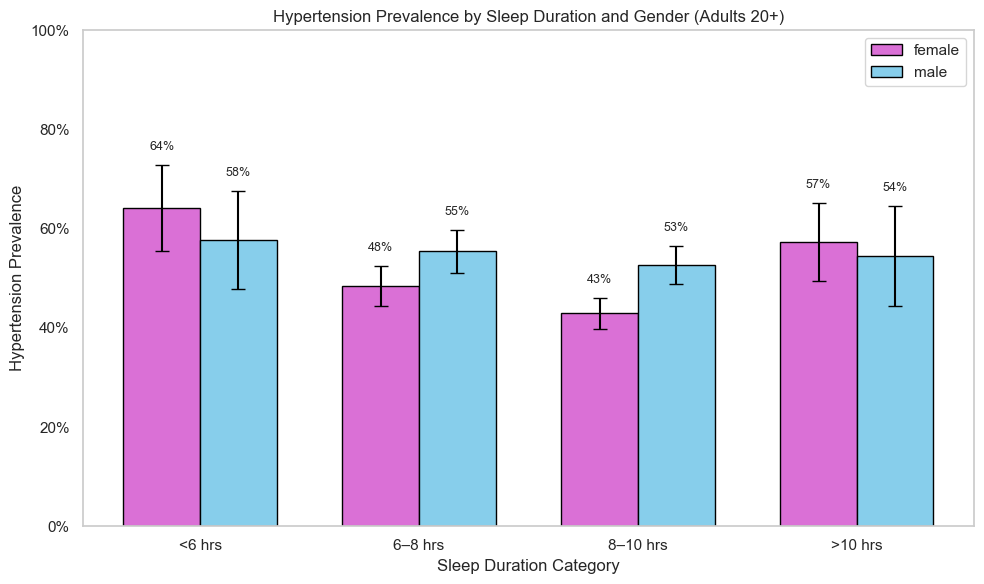

In [96]:
# --- Weighted prevalence function ---
def compute_weighted_ci(group):
    weights = group['Exam_Weight']
    p = np.average(group['Hypertensive'], weights=weights)
    weight_sum = weights.sum()
    weight_sq_sum = (weights ** 2).sum()
    n_eff = (weight_sum ** 2) / weight_sq_sum
    se = np.sqrt(p * (1 - p) / n_eff)
    ci_lower = max(0, p - 1.96 * se)
    ci_upper = min(1, p + 1.96 * se)
    return pd.Series({
        'Weighted_Hypertension_Prevalence': p,
        'CI_Lower': ci_lower,
        'CI_Upper': ci_upper,
        'Weighted_Population': weight_sum
    })

# --- Group by gender and sleep category ---
results = df.groupby(['Gender', 'sleep_category']).apply(compute_weighted_ci).reset_index()

# --- Define consistent sleep category order ---
sleep_categories = ['<6 hrs', '6–8 hrs', '8–10 hrs', '>10 hrs']
results['sleep_category'] = pd.Categorical(results['sleep_category'], categories=sleep_categories, ordered=True)

# --- Plotting ---
fig, ax = plt.subplots(figsize=(10, 6))
genders = results['Gender'].unique()
bar_width = 0.35
x = np.arange(len(sleep_categories))
colors = {'male': 'skyblue', 'female': 'orchid'}

for i, gender in enumerate(genders):
    gender_data = (
        results[results['Gender'] == gender]
        .set_index('sleep_category')
        .reindex(sleep_categories)
    )

    bar_pos = x + (i - 0.5) * bar_width
    bars = ax.bar(
        bar_pos,
        gender_data['Weighted_Hypertension_Prevalence'],
        bar_width,
        label=gender,
        color = colors[gender],
        edgecolor='black'
    )

    ax.errorbar(
        bar_pos,
        gender_data['Weighted_Hypertension_Prevalence'],
        yerr=[
            gender_data['Weighted_Hypertension_Prevalence'] - gender_data['CI_Lower'],
            gender_data['CI_Upper'] - gender_data['Weighted_Hypertension_Prevalence']
        ],
        fmt='none', ecolor='black', capsize=5
    )


    # Labels
    for j, (_, row) in enumerate(gender_data.iterrows()):
        if pd.isna(row['Weighted_Hypertension_Prevalence']):
            continue
        ax.text(bar_pos[j], row['CI_Upper'] + 0.03,
                f"{int(round(row['Weighted_Hypertension_Prevalence'] * 100))}%", ha='center', fontsize=9)

# --- Final touches ---
ax.set_xticks(x)
ax.set_xticklabels(sleep_categories)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
ax.set_title("Hypertension Prevalence by Sleep Duration and Gender (Adults 20+)")
ax.set_xlabel("Sleep Duration Category")
ax.set_ylabel("Hypertension Prevalence")
ax.set_ylim(0, 1)
ax.grid(False)
ax.legend()
plt.tight_layout()

# --- Save figure ---
plt.savefig("../visualization/hypertension_by_sleep_duration_gender.png", dpi=300, bbox_inches='tight')

# --- Show plot ---
plt.show()

# Reversing the display order of Gender to match the presentation

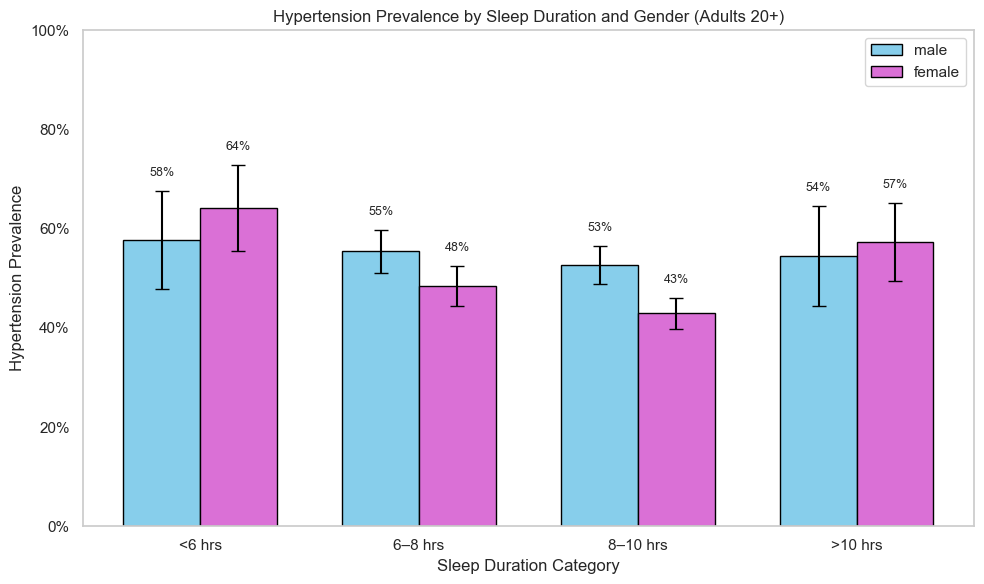

In [99]:
# --- Weighted prevalence function ---
def compute_weighted_ci(group):
    weights = group['Exam_Weight']
    p = np.average(group['Hypertensive'], weights=weights)
    weight_sum = weights.sum()
    weight_sq_sum = (weights ** 2).sum()
    n_eff = (weight_sum ** 2) / weight_sq_sum
    se = np.sqrt(p * (1 - p) / n_eff)
    ci_lower = max(0, p - 1.96 * se)
    ci_upper = min(1, p + 1.96 * se)
    return pd.Series({
        'Weighted_Hypertension_Prevalence': p,
        'CI_Lower': ci_lower,
        'CI_Upper': ci_upper,
        'Weighted_Population': weight_sum
    })

# --- Group by gender and sleep category ---
results = df.groupby(['Gender', 'sleep_category']).apply(compute_weighted_ci).reset_index()

# --- Define consistent sleep category order ---
sleep_categories = ['<6 hrs', '6–8 hrs', '8–10 hrs', '>10 hrs']
results['sleep_category'] = pd.Categorical(results['sleep_category'], categories=sleep_categories, ordered=True)

# --- Plotting ---
fig, ax = plt.subplots(figsize=(10, 6))
genders = results['Gender'].unique()
genders = list(genders)[::-1] # Gender order reversed to make Male appear on left

bar_width = 0.35
x = np.arange(len(sleep_categories))
colors = {'male': 'skyblue', 'female': 'orchid'}

for i, gender in enumerate(genders):
    gender_data = (
        results[results['Gender'] == gender]
        .set_index('sleep_category')
        .reindex(sleep_categories)
    )

    bar_pos = x + (i - 0.5) * bar_width
    bars = ax.bar(
        bar_pos,
        gender_data['Weighted_Hypertension_Prevalence'],
        bar_width,
        label=gender,
        color = colors[gender],
        edgecolor='black'
    )

    ax.errorbar(
        bar_pos,
        gender_data['Weighted_Hypertension_Prevalence'],
        yerr=[
            gender_data['Weighted_Hypertension_Prevalence'] - gender_data['CI_Lower'],
            gender_data['CI_Upper'] - gender_data['Weighted_Hypertension_Prevalence']
        ],
        fmt='none', ecolor='black', capsize=5
    )


    # Labels
    for j, (_, row) in enumerate(gender_data.iterrows()):
        if pd.isna(row['Weighted_Hypertension_Prevalence']):
            continue
        ax.text(bar_pos[j], row['CI_Upper'] + 0.03,
                f"{int(round(row['Weighted_Hypertension_Prevalence'] * 100))}%", ha='center', fontsize=9)

# --- Final touches ---
ax.set_xticks(x)
ax.set_xticklabels(sleep_categories)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
ax.set_title("Hypertension Prevalence by Sleep Duration and Gender (Adults 20+)")
ax.set_xlabel("Sleep Duration Category")
ax.set_ylabel("Hypertension Prevalence")
ax.set_ylim(0, 1)
ax.grid(False)
ax.legend()
plt.tight_layout()

# --- Save figure ---
plt.savefig("../visualization/hypertension_by_sleep_duration_gender.png", dpi=300, bbox_inches='tight')

# --- Show plot ---
plt.show()

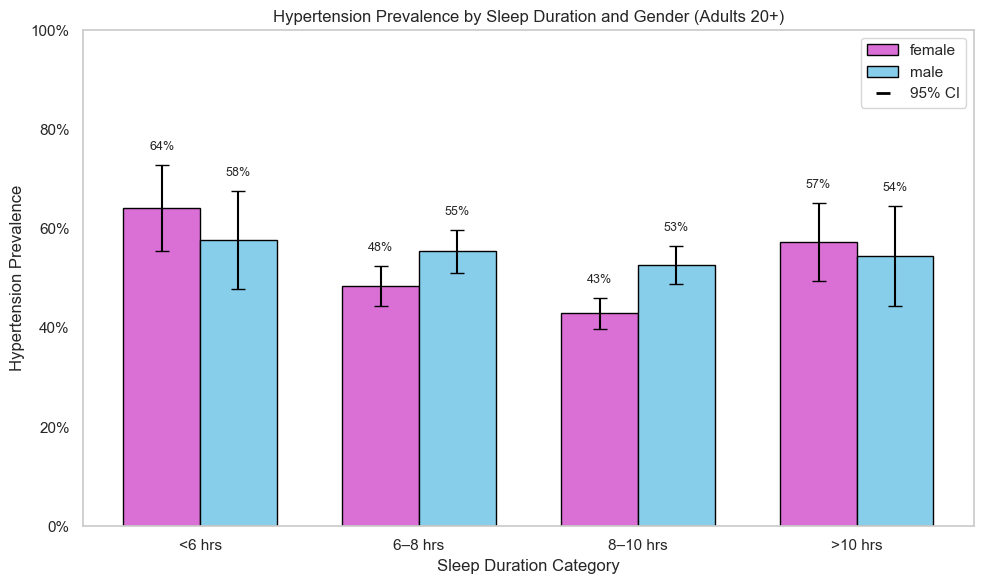

In [97]:
import matplotlib.lines as mlines

# --- Plotting ---
fig, ax = plt.subplots(figsize=(10, 6))
genders = results['Gender'].unique()
bar_width = 0.35
x = np.arange(len(sleep_categories))
colors = {'male': 'skyblue', 'female': 'orchid'}

bars_handles = []  # to collect bars for legend
for i, gender in enumerate(genders):
    gender_data = (
        results[results['Gender'] == gender]
        .set_index('sleep_category')
        .reindex(sleep_categories)
    )

    bar_pos = x + (i - 0.5) * bar_width
    bars = ax.bar(
        bar_pos,
        gender_data['Weighted_Hypertension_Prevalence'],
        bar_width,
        label=gender,
        color=colors[gender],
        edgecolor='black'
    )
    bars_handles.append(bars)

    ax.errorbar(
        bar_pos,
        gender_data['Weighted_Hypertension_Prevalence'],
        yerr=[
            gender_data['Weighted_Hypertension_Prevalence'] - gender_data['CI_Lower'],
            gender_data['CI_Upper'] - gender_data['Weighted_Hypertension_Prevalence']
        ],
        fmt='none', ecolor='black', capsize=5
    )

    # Labels
    for j, (_, row) in enumerate(gender_data.iterrows()):
        if pd.isna(row['Weighted_Hypertension_Prevalence']):
            continue
        ax.text(bar_pos[j], row['CI_Upper'] + 0.03,
                f"{int(round(row['Weighted_Hypertension_Prevalence'] * 100))}%", ha='center', fontsize=9)

# Create a custom legend handle for the CI error bars
ci_handle = mlines.Line2D([], [], color='black', marker='_', markersize=10, label='95% CI', linestyle='None', markeredgewidth=2)

# --- Final touches ---
ax.set_xticks(x)
ax.set_xticklabels(sleep_categories)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
ax.set_title("Hypertension Prevalence by Sleep Duration and Gender (Adults 20+)")
ax.set_xlabel("Sleep Duration Category")
ax.set_ylabel("Hypertension Prevalence")
ax.set_ylim(0, 1)
ax.grid(False)

# Add legend with bars for gender and error bar for CI
ax.legend(handles=[bars_handles[0], bars_handles[1], ci_handle], labels=[genders[0], genders[1], '95% CI'])

plt.tight_layout()

# --- Save figure ---
plt.savefig("../visualization/hypertension_by_sleep_duration_gender.png", dpi=300, bbox_inches='tight')

# --- Show plot ---
plt.show()

In [ ]:
# --- CI Computation ---
def compute_weighted_ci(group):
    weights = group['Exam_Weight']
    if weights.sum() == 0:
        return pd.Series({
            'Weighted_Hypertension_Prevalence': np.nan,
            'CI_Lower': np.nan,
            'CI_Upper': np.nan,
            'Weighted_Population': 0
        })
    p = np.average(group['Hypertensive'], weights=weights)
    weight_sum = weights.sum()
    weight_sq_sum = (weights**2).sum()
    n_eff = (weight_sum ** 2) / weight_sq_sum
    se = np.sqrt(p * (1 - p) / n_eff)
    ci_lower = max(0, p - 1.96 * se)
    ci_upper = min(1, p + 1.96 * se)
    return pd.Series({
        'Weighted_Hypertension_Prevalence': p,
        'CI_Lower': ci_lower,
        'CI_Upper': ci_upper,
        'Weighted_Population': weight_sum
    })

In [ ]:
plt.figure(figsize=(10,6))
for age_group in age_labels:
    sub = results[results["Age_Group"] == age_group]
    plt.plot(sleep_categories, sub["Weighted_Hypertension_Prevalence"], label=age_group, marker='o')

plt.title("Hypertension Prevalence by Sleep Duration Across Age Groups")
plt.xlabel("Sleep Duration")
plt.ylabel("Hypertension Prevalence")
plt.ylim(0, 1)
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.legend(title="Age Group")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# 4. Sleep Category vs Hypertension (overall)
sleep_stats = df.groupby('sleep_category').apply(compute_weighted_ci).reset_index()
sleep_stats['Gender'] = 'All'
plot_grouped_prevalence_fixed(sleep_stats, 'sleep_category', 'Gender', "Hypertension by Sleep Duration")

In [ ]:
# Recreate Age_Group column using provided age bins and labels
age_bins = [20, 30, 40, 50, 60, 70, 80, np.inf]
age_labels = ['20-29', '30-39', '40-49', '50-59', '60-69', '70-79', '80+']

# Apply binning on 'Age_Years' column to create 'Age_Group'
df['Age_Group'] = pd.cut(df['Age_Years'], bins=age_bins, labels=age_labels, right=False)

# Proceed with analysis and plotting
df_age_gender = preprocess_data(df, ['Age_Group', 'Gender'])
age_gender_stats = df_age_gender.groupby(['Age_Group', 'Gender']).apply(compute_weighted_ci).reset_index()
plot_grouped_prevalence_fixed(age_gender_stats, 'Age_Group', 'Gender', "Hypertension by Age Group and Gender")

In [ ]:
df.columns